<a href="https://colab.research.google.com/github/lorenzofaoro/porject-data-fusion3D-Object-Detection-with-LiDAR-Camera-Fusion/blob/main/YOLOv11m_BDD100K_Exp2_Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YOLOv11m — Esperimento 2: Augmentation Mirata
## Fine-tuning da checkpoint baseline su BDD100K — Google Colab GPU A100

**Obiettivo dell'esperimento:**
Migliorare la detection su scene notturne e classi rare (traffic sign, pedestrian) rispetto al baseline, mediante:
- Aumento del jitter di luminosità/saturazione (`hsv_v`, `hsv_v`)
- Riduzione del mosaic per preservare oggetti piccoli
- Copy-paste augmentation per classi sotto-rappresentate
- Maggiore regolarizzazione (`weight_decay`)
- NMS più aggressivo per ridurre box duplicati (`iou=0.5`)

**Parte da:** checkpoint `best.pt` del training baseline (20 epoche)
**Durata prevista:** ~15 epoche (~2-3 ore su A100)

---

## Prerequisiti:
1. Runtime → Cambia tipo di runtime → **GPU A100**
2. Dataset BDD100K già presente su Google Drive in `MyDrive/UNI/UNIPARMA/ADAS/BDD100K/`
3. Checkpoint baseline disponibile in Drive


## STEP 1: Installazione dipendenze

In [ ]:
5# Installa librerie necessarie
!pip install ultralytics -q
!pip install pycocotools -q
!pip install pandas seaborn thop -q

print("Installazione completata!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 54.1 MB/s eta 0:00:00
Installazione completata!


## STEP 2: Import librerie

In [ ]:
import os
import time
import json
import yaml
import torch
import shutil
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from google.colab import drive

print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponibile: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU: {gpu_name}")
    print(f"Memoria GPU: {gpu_mem:.1f} GB")

    if 'A100' in gpu_name:
        print("\nGPU A100 rilevata - configurazione ottimale!")
    else:
        print(f"\nATTENZIONE: GPU {gpu_name} rilevata (non A100)")
        print("Il notebook funzionera' comunque ma piu' lentamente")
else:
    print("\nERRORE: Nessuna GPU disponibile!")
    print("Vai su Runtime -> Cambia tipo di runtime -> GPU A100")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch: 2.10.0+cu128
CUDA disponibile: True
GPU: NVIDIA A100-SXM4-40GB
Memoria GPU: 39.5 GB

GPU A100 rilevata - configurazione ottimale!


## STEP 3: Monta Google Drive

**IMPORTANTE**: Modifica il path `GDRIVE_ROOT` con il tuo percorso in Google Drive.

In [ ]:
# Monta Google Drive
drive.mount('/content/drive')

# ==========================================
# MODIFICA QUESTO PATH CON IL TUO PERCORSO
# ==========================================
GDRIVE_ROOT = '/content/drive/MyDrive/UNI/UNIPARMA/ADAS'
# ==========================================

print(f"Dataset root: {GDRIVE_ROOT}")
print(f"Esiste: {os.path.exists(GDRIVE_ROOT)}")

if os.path.exists(GDRIVE_ROOT):
    print("\nContenuto:")
    for item in sorted(os.listdir(GDRIVE_ROOT)):
        item_path = os.path.join(GDRIVE_ROOT, item)
        if os.path.isdir(item_path):
            n = len(os.listdir(item_path))
            print(f"  {item}/ ({n} items)")
        else:
            print(f"  {item}")
else:
    print("\nERRORE: Path non trovato!")
    print("Verifica il percorso in GDRIVE_ROOT")

Mounted at /content/drive
Dataset root: /content/drive/MyDrive/UNI/UNIPARMA/ADAS
Esiste: True

Contenuto:
  BDD100K/ (14 items)
  REPORT_FINALE_YOLOv11m_20260506_100430/ (14 items)
  Robot_Parme_Simulink_V2.slx
  runs/ (2 items)
  slides teoria/ (16 items)


## STEP 4: Verifica struttura dataset

In [ ]:
# Verifica path del dataset (struttura: train/ e val/ diretti)
TRAIN_DIR = f'{GDRIVE_ROOT}/train'
VAL_DIR = f'{GDRIVE_ROOT}/val'

print("Verifica struttura dataset:")
print("=" * 60)

paths_ok = True

for name, path in [('Train', TRAIN_DIR), ('Val', VAL_DIR)]:
    exists = os.path.exists(path)
    status = "OK" if exists else "MANCANTE"
    print(f"  [{status}] {name}: {path}")

    if exists:
        items = os.listdir(path)

        # Conta immagini e labels
        n_jpg = len([f for f in items if f.endswith('.jpg')])
        n_png = len([f for f in items if f.endswith('.png')])
        n_txt = len([f for f in items if f.endswith('.txt')])

        # Controlla sottocartelle
        subdirs = [f for f in items if os.path.isdir(os.path.join(path, f))]

        print(f"         -> Immagini: {n_jpg + n_png:,} (jpg: {n_jpg}, png: {n_png})")
        print(f"         -> Labels .txt: {n_txt:,}")

        if subdirs:
            print(f"         -> Sottocartelle: {subdirs}")
            # Se ci sono sottocartelle images/labels, aggiorna i path
            if 'images' in subdirs:
                sub_img = os.path.join(path, 'images')
                n_sub = len([f for f in os.listdir(sub_img) if f.endswith(('.jpg', '.png'))])
                print(f"         -> {name}/images/: {n_sub:,} immagini")
    else:
        paths_ok = False

# Leggi data.yaml esistente (se presente)
yaml_original = f'{GDRIVE_ROOT}/data.yaml'
print(f"\ndata.yaml esistente:")
if os.path.exists(yaml_original):
    print(f"  [OK] Trovato: {yaml_original}")
    with open(yaml_original, 'r') as f:
        content = f.read()
    print(f"\n  Contenuto:")
    print("  " + "-" * 56)
    for line in content.split('\n'):
        print(f"  {line}")
    print("  " + "-" * 56)
else:
    print(f"  [INFO] Non trovato, verra' creato nuovo")

print("=" * 60)

if not paths_ok:
    print("\nERRORE: Alcuni path non esistono!")
    print("Verifica la struttura del dataset in Google Drive")
else:
    print("\nTutto OK! Dataset pronto.")

Verifica struttura dataset:
  [MANCANTE] Train: /content/drive/MyDrive/UNI/UNIPARMA/ADAS/train
  [MANCANTE] Val: /content/drive/MyDrive/UNI/UNIPARMA/ADAS/val

data.yaml esistente:
  [INFO] Non trovato, verra' creato nuovo

ERRORE: Alcuni path non esistono!
Verifica la struttura del dataset in Google Drive


## STEP 5: Configurazione dataset YAML

In [ ]:
import yaml
import os

# 1. Definizione del percorso base
# Il percorso deve puntare alla cartella che CONTIENE 'val'
DATASET_ROOT = '/content/dataset'

# 2. Nuova Mappatura Classi (quella che hai ricavato dalle analisi)
CLASS_NAMES = [
    'bicycle',       # 0
    'bus',           # 1
    'car',           # 2
    'motorcycle',    # 3
    'pedestrian',    # 4
    'rider',         # 5
    'traffic light', # 6
    'traffic sign',  # 7
    'train',         # 8
    'truck'          # 9
]

# 3. Configurazione YAML
# Se le immagini sono direttamente in 'val', scriviamo solo 'val'
data_yaml = {
    'path': DATASET_ROOT,
    'train': 'train',
    'val': 'val',
    'test': 'val',
    'nc': len(CLASS_NAMES),
    'names': CLASS_NAMES
}

# 4. Salvataggio nel workspace
WORK_DIR = '/content/workspace'
os.makedirs(WORK_DIR, exist_ok=True)
yaml_path = f'{WORK_DIR}/bdd100k.yaml'

with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"File YAML creato correttamente: {yaml_path}")
print("Configurato per cercare immagini direttamente in /BDD100K/val/")

File YAML creato correttamente: /content/workspace/bdd100k.yaml
Configurato per cercare immagini direttamente in /BDD100K/val/


## STEP 6: Configurazione training — Esperimento 2 (Augmentation mirata)

**Modifiche rispetto al baseline:**
| Parametro | Baseline | Esperimento 2 | Motivazione |
|---|---|---|---|
| `name` | `yolov11m_bdd100k_1280_finetuning` | `yolov11m_bdd100k_1280_exp2_augmentation` | Cartella Drive separata |
| `epochs` | 20 | 15 | Fine-tuning da checkpoint, non da zero |
| `lr0` | 0.0005 | 0.0005 | Invariato |
| `lrf` | 0.01 | 0.001 | Decay finale più aggressivo |
| `weight_decay` | 0.0005 | 0.001 | Riduce over-detection su car |
| `hsv_v` | ~0.4 | 0.6 | Più variazione luminosità → scene notturne |
| `hsv_s` | ~0.7 | 0.8 | Più variazione saturazione |
| `mosaic` | 1.0 | 0.7 | Meno frammentazione oggetti piccoli |
| `copy_paste` | 0.0 | 0.3 | Aumenta esempi sintetici classi rare |
| `iou` (NMS) | non impostato | 0.5 | Riduce box duplicati |


In [ ]:
# Configurazione GPU
if torch.cuda.is_available():
    device = 0
    gpu_name = torch.cuda.get_device_name(0)

    if 'A100' in gpu_name:
        batch_size = 16
        workers = 8
        print('Configurazione A100: OTTIMALE (Fine-tuning 1280px)')
    elif 'V100' in gpu_name:
        batch_size = 8
        workers = 6
        print('Configurazione V100: RISCHIOSA a 1280px')
    else:
        batch_size = 4
        workers = 4
        print(f'GPU {gpu_name}: batch ridotto per alta risoluzione')
else:
    device = 'cpu'
    batch_size = 1
    workers = 2
    print('CPU mode - sconsigliato per 1280px!')

# --- MODIFICATO: 5 epoche per fine-tuning dal checkpoint ---
EPOCHS = 5

# Nome run esperimento 2 — cartella Drive separata dal baseline
RUN_NAME = 'yolov11m_bdd100k_1280_exp2_augmentation'

training_args = {
    'data': yaml_path,
    'epochs': EPOCHS,
    'imgsz': 1280,
    'batch': batch_size,
    'device': device,
    'workers': workers,

    # --- MODIFICATO: nuova cartella per isolare i risultati dell'esperimento 2 ---
    'project': '/content/drive/MyDrive/UNI/UNIPARMA/ADAS/runs',
    'name': RUN_NAME,
    'exist_ok': True,

    # Optimizer
    'optimizer': 'AdamW',
    'lr0': 0.0005,
    # --- MODIFICATO: decay finale più aggressivo ---
    'lrf': 0.001,
    # --- MODIFICATO: weight_decay raddoppiato vs baseline ---
    'weight_decay': 0.001,

    # Loss weights (invariati)
    'box': 10.0,
    'cls': 1.0,
    'dfl': 1.5,

    # --- NUOVO: augmentation mirata ---
    'hsv_v': 0.6,       # era ~0.4 (default YOLO): più variazione luminosità per scene notturne
    'hsv_s': 0.8,       # era ~0.7: più variazione saturazione
    'mosaic': 0.7,      # era 1.0: ridotto per non frammentare traffic sign
    'copy_paste': 0.3,  # era 0.0: incolla istanze di classi rare in scene nuove

    # --- MODIFICATO: iou NMS abbassato per ridurre box duplicati ---
    'iou': 0.5,

    # Validation & Saving
    'val': True,
    'save': True,
    'save_period': 5,
    'patience': 10,
    'cache': False,
    'plots': True,
    'verbose': True,
}

print(f'\nParametri training — Esperimento 2 (Augmentation mirata):')
print(f'  Epochs:        {EPOCHS}')
print(f'  Batch size:    {batch_size}')
print(f'  Image size:    {training_args["imgsz"]}')
print(f'  lr0:           {training_args["lr0"]}')
print(f'  lrf:           {training_args["lrf"]}')
print(f'  weight_decay:  {training_args["weight_decay"]}')
print(f'  hsv_v:         {training_args["hsv_v"]}')
print(f'  hsv_s:         {training_args["hsv_s"]}')
print(f'  mosaic:        {training_args["mosaic"]}')
print(f'  copy_paste:    {training_args["copy_paste"]}')
print(f'  iou (NMS):     {training_args["iou"]}')
print(f'  Output Drive:  /content/drive/MyDrive/UNI/UNIPARMA/ADAS/runs/{RUN_NAME}')


Configurazione A100: OTTIMALE (Fine-tuning 1280px)

Parametri training — Esperimento 2 (Augmentation mirata):
  Epochs:        5
  Batch size:    16
  Image size:    1280
  lr0:           0.0005
  lrf:           0.001
  weight_decay:  0.001
  hsv_v:         0.6
  hsv_s:         0.8
  mosaic:        0.7
  copy_paste:    0.3
  iou (NMS):     0.5
  Output Drive:  /content/drive/MyDrive/UNI/UNIPARMA/ADAS/runs/yolov11m_bdd100k_1280_exp2_augmentation


In [ ]:
import shutil, os

LOCAL_DATASET = '/content/dataset'

if not os.path.exists(f'{LOCAL_DATASET}/train'):
    print("Copio train in locale (20k immagini, ~15-20 min)...")
    shutil.copytree(
        '/content/drive/MyDrive/UNI/UNIPARMA/ADAS/BDD100K/train',
        f'{LOCAL_DATASET}/train'
    )
    print("Train copiato!")
else:
    print("Train già presente in locale.")

if not os.path.exists(f'{LOCAL_DATASET}/val'):
    print("Copio val in locale...")
    shutil.copytree(
        '/content/drive/MyDrive/UNI/UNIPARMA/ADAS/BDD100K/val',
        f'{LOCAL_DATASET}/val'
    )
    print("Val copiato!")
else:
    print("Val già presente in locale.")

Train già presente in locale.
Copio val in locale...
Val copiato!


## STEP 7: Training — fine-tuning dal checkpoint baseline

**Durata prevista:** ~2-3 ore su A100 a 1280px (15 epoche).
Monitora la `val/loss` ogni 5 epoche: se non scende rispetto al baseline, puoi fermarti e usare il dato come risultato negativo.


In [ ]:
# Percorso del checkpoint baseline (best.pt del training originale)
path_modello_ottimizzato = '/content/drive/MyDrive/UNI/UNIPARMA/ADAS/runs/yolov11m_bdd100k_1280_exp2_augmentation/weights/last.pt'
print(f'Caricamento checkpoint baseline da:')
print(f'  {path_modello_ottimizzato}')
model = YOLO(path_modello_ottimizzato)

total_params = sum(p.numel() for p in model.model.parameters())
print(f'Modello caricato!')
print(f'  Parametri totali: {total_params:,}')
print(f'  Dimensione: ~{total_params * 4 / (1024**2):.1f} MB')

print('\n' + '=' * 60)
print('AVVIO TRAINING — ESPERIMENTO 2 (Augmentation mirata)')
print('=' * 60)
print(f'Inizio: {time.strftime("%Y-%m-%d %H:%M:%S")}')
print()

start_time = time.time()
results = model.train(**training_args)
training_duration = time.time() - start_time

print('\n' + '=' * 60)
print('TRAINING COMPLETATO!')
print('=' * 60)
print(f'Fine: {time.strftime("%Y-%m-%d %H:%M:%S")}')
print(f'Durata totale: {training_duration/3600:.2f} ore ({training_duration/60:.1f} minuti)')


Caricamento checkpoint baseline da:
  /content/drive/MyDrive/UNI/UNIPARMA/ADAS/runs/yolov11m_bdd100k_1280_exp2_augmentation/weights/last.pt
Modello caricato!
  Parametri totali: 20,060,718
  Dimensione: ~76.5 MB

AVVIO TRAINING — ESPERIMENTO 2 (Augmentation mirata)
Inizio: 2026-05-12 09:22:38

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=10.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/workspace/bdd100k.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.8, hsv_v=0.6, imgsz=

In [ ]:
# (Cella riservata — resume non necessario per l'esperimento 2)
# Se il training si interrompe, ricarica best.pt o last.pt
# e riavvia da STEP 7 con resume=False e gli stessi training_args.


In [ ]:
# (Cella riservata — il file YAML viene creato allo STEP 5, non serve ricrearlo)


## STEP 8: Valutazione completa — Esperimento 2

Calcoliamo le metriche globali sul validation set. I risultati vengono salvati nella cartella Drive dell'esperimento 2.
**Confronta i valori con il baseline** (soprattutto mAP su `traffic sign` e `recall` su scene notturne).


In [ ]:
from ultralytics import YOLO
import os

# --- MODIFICATO: punta alla cartella dell'esperimento 2 ---
results_dir = f'/content/drive/MyDrive/UNI/UNIPARMA/ADAS/runs/{RUN_NAME}'
best_model_path = f'{results_dir}/weights/best.pt'
yaml_path = '/content/workspace/bdd100k.yaml'

print(f'Caricamento best model (exp2):')
print(f'  {best_model_path}')
best_model = YOLO(best_model_path)

# Forzatura mappatura classi (invariata)
new_names = {
    0: 'bicycle', 1: 'bus', 2: 'car', 3: 'motorcycle',
    4: 'pedestrian', 5: 'rider', 6: 'traffic light',
    7: 'traffic sign', 8: 'train', 9: 'truck'
}
best_model.model.names = new_names
print('Mappatura classi forzata correttamente nel modello.')

print('\nEsecuzione validation completa in corso (imgsz=1280)...')
metrics = best_model.val(
    data=yaml_path,
    split='val',
    save_json=True,
    plots=True,
    conf=0.001,     # Necessaria per curva PR completa
    # --- MODIFICATO: iou coerente con il training exp2 ---
    iou=0.5,
    imgsz=1280,
    # Salva i plot nella sottocartella val_results dell'exp2
    project='/content/drive/MyDrive/UNI/UNIPARMA/ADAS/runs',
    name=f'{RUN_NAME}/val_results',
    exist_ok=True,
)

# Estrazione metriche globali
map50     = float(metrics.box.map50)
map50_95  = float(metrics.box.map)
precision = float(metrics.box.mp)
recall    = float(metrics.box.mr)

if (precision + recall) > 0:
    f1_global = 2 * (precision * recall) / (precision + recall)
else:
    f1_global = 0

print('\n' + '=' * 60)
print('METRICHE GLOBALI — ESPERIMENTO 2 (Augmentation mirata)')
print('=' * 60)
print(f'  mAP@50:       {map50:.4f} ({map50*100:.2f}%)')
print(f'  mAP@50-95:    {map50_95:.4f} ({map50_95*100:.2f}%)')
print(f'  Precision:    {precision:.4f} ({precision*100:.2f}%)')
print(f'  Recall:       {recall:.4f} ({recall*100:.2f}%)')
print(f'  F1-Score:     {f1_global:.4f} ({f1_global*100:.2f}%)')
print('=' * 60)
print(f'\nRisultati salvati in: {results_dir}')


Caricamento best model (exp2):
  /content/drive/MyDrive/UNI/UNIPARMA/ADAS/runs/yolov11m_bdd100k_1280_exp2_augmentation/weights/best.pt
Mappatura classi forzata correttamente nel modello.

Esecuzione validation completa in corso (imgsz=1280)...
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11m summary (fused): 126 layers, 20,037,742 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1854.6±561.3 MB/s, size: 63.1 KB)
val: Scanning /content/dataset/val.cache... 2002 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2005/2005 841.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 126/126 4.5it/s 28.1s
                   all       2005      37112       0.59      0.499      0.526      0.277
               bicycle        109        208      0.611      0.413      0.431       0.18
                   bus        229        305      0.597 

## STEP 9: Metriche per classe

In [ ]:
import numpy as np
import pandas as pd

# 1. DEFINISCI CLASS_NAMES (Essenziale se la sessione si è resettata)
CLASS_NAMES = [
    'pedestrian', 'rider', 'car', 'truck', 'bus',
    'train', 'motorcycle', 'bicycle', 'traffic light', 'traffic sign'
]

print("METRICHE PER CLASSE")
print("=" * 95)
print(f"{'Classe':<20} {'Precision':>10} {'Recall':>10} {'F1':>10} {'mAP@50':>10} {'mAP@50-95':>12}")
print("-" * 95)

per_class_data = []

# 2. ITERAZIONE SULLE METRICHE
for i, class_name in enumerate(CLASS_NAMES):
    # Verifichiamo che l'indice esista nelle metriche calcolate da YOLO
    if i < len(metrics.box.ap50):
        p = float(metrics.box.p[i]) if i < len(metrics.box.p) else 0.0
        r = float(metrics.box.r[i]) if i < len(metrics.box.r) else 0.0
        ap50 = float(metrics.box.ap50[i])
        ap = float(metrics.box.ap[i]) # Questo è il mAP@50-95 per classe

        # Calcolo F1-Score per classe
        f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0.0

        print(f"{class_name:<20} {p:>10.4f} {r:>10.4f} {f1:>10.4f} {ap50:>10.4f} {ap:>12.4f}")

        per_class_data.append({
            'class': class_name,
            'precision': p,
            'recall': r,
            'f1': f1,
            'mAP50': ap50,
            'mAP50-95': ap
        })

print("-" * 95)

# 3. CALCOLO MEDIE (Utilizzando NumPy come nel tuo codice originale)
if per_class_data:
    avg_p = np.mean([d['precision'] for d in per_class_data])
    avg_r = np.mean([d['recall'] for d in per_class_data])
    avg_f1 = np.mean([d['f1'] for d in per_class_data])
    avg_ap50 = np.mean([d['mAP50'] for d in per_class_data])
    avg_ap = np.mean([d['mAP50-95'] for d in per_class_data])

    print(f"{'MEDIA':<20} {avg_p:>10.4f} {avg_r:>10.4f} {avg_f1:>10.4f} {avg_ap50:>10.4f} {avg_ap:>12.4f}")
print("=" * 95)

# 4. CREAZIONE DATAFRAME PER ANALISI FUTURA
df_per_class = pd.DataFrame(per_class_data)
print("\nDataFrame creato con", len(df_per_class), "classi")

METRICHE PER CLASSE
Classe                Precision     Recall         F1     mAP@50    mAP@50-95
-----------------------------------------------------------------------------------------------
pedestrian               0.6058     0.5048     0.5507     0.5160       0.2488
rider                    0.6223     0.5869     0.6041     0.6169       0.4687
car                      0.8430     0.7572     0.7978     0.8378       0.5169
truck                    0.6587     0.4756     0.5524     0.5200       0.2527
bus                      0.7889     0.6410     0.7073     0.7247       0.3771
train                    0.7612     0.5772     0.6566     0.5956       0.3126
motorcycle               0.7588     0.6776     0.7159     0.7187       0.2810
bicycle                  0.7406     0.6931     0.7161     0.7488       0.4086
traffic light            1.0000     0.0000     0.0000     0.0000       0.0000
traffic sign             0.6050     0.6257     0.6152     0.6249       0.4443
--------------------------

## STEP 10: Metriche COCO complete (APs, APm, APl)

Calcoliamo le metriche per dimensione degli oggetti usando pycocotools.

In [ ]:
import glob
import os
import numpy as np

# --- MODIFICATO: punta alla cartella dell'esperimento 2 ---
results_dir = f'/content/drive/MyDrive/UNI/UNIPARMA/ADAS/runs/{RUN_NAME}'

# Assicuriamoci che i percorsi siano quelli corretti dal Blocco 8
# results_dir deve puntare alla cartella del fine-tuning a 1280px

# 1. Cerca il file delle predizioni JSON (generato da save_json=True nel Blocco 8)
predictions_json = None
# Cerchiamo ricorsivamente nella cartella dei risultati
json_files = glob.glob(f'{results_dir}/**/*.json', recursive=True)

for f in json_files:
    if 'predictions' in f.lower():
        predictions_json = f
        break

print("METRICHE COCO-STYLE (Standard Internazionale)")
print("=" * 60)

# 2. Inizializzazione metriche
# Estraiamo i valori base già calcolati da YOLO
# map50_95 e map50 arrivano dalle variabili definite nel Blocco 8
coco_style_metrics = {
    'AP': map50_95 * 100,           # mAP @ IoU 0.5:0.95
    'AP50': map50 * 100,            # mAP @ IoU 0.5
    'AP75': 0.0,                    # Precisione con IoU più rigoroso
    'APs': 0.0,                     # Oggetti Piccoli (es. semafori lontani)
    'APm': 0.0,                     # Oggetti Medi
    'APl': 0.0,                     # Oggetti Grandi
}

# 3. Estrazione AP75
# YOLO calcola le AP su 10 step di IoU (0.50, 0.55, ..., 0.95)
# L'indice [5] corrisponde esattamente a IoU 0.75
if hasattr(metrics.box, 'maps'):
    # metrics.box.maps contiene il mAP per ogni soglia IoU
    all_iou_maps = metrics.box.maps
    if len(all_iou_maps) > 5:
        coco_style_metrics['AP75'] = all_iou_maps[5] * 100

# 4. Gestione AP per Dimensione (APs, APm, APl)
if predictions_json and os.path.exists(predictions_json):
    print(f"File predizioni trovato: {os.path.basename(predictions_json)}")
    print("Calcolo in corso basato sui risultati della validazione...")

    # Nota: Senza convertire l'intero dataset BDD100K in formato .json (COCO),
    # YOLO non può popolare APs/APm/APl automaticamente.
    # Tuttavia, possiamo usare una stima basata sulla complessità del dataset.
else:
    print("ATTENZIONE: File JSON non trovato. Assicurati che 'save_json=True' sia attivo in .val()")

# 5. Visualizzazione Risultati Finale
print("\nSintesi Metriche COCO:")
print("-" * 30)
for key, value in coco_style_metrics.items():
    # Se il valore è 0 e non abbiamo i dati COCO, mettiamo "N/A" per APs/APm/APl
    if value == 0 and key in ['APs', 'APm', 'APl']:
        print(f"  {key:<8} {'N/A':>8}")
    else:
        print(f"  {key:<8} {value:>7.2f}%")

print("-" * 30)
print("=" * 60)
print("INFO: Per sbloccare APs/APm/APl (Small/Medium/Large),")
print("è necessario fornire il file ground_truth in formato COCO (.json).")

METRICHE COCO-STYLE (Standard Internazionale)
ATTENZIONE: File JSON non trovato. Assicurati che 'save_json=True' sia attivo in .val()

Sintesi Metriche COCO:
------------------------------
  AP         33.11%
  AP50       59.03%
  AP75       31.26%
  APs           N/A
  APm           N/A
  APl           N/A
------------------------------
INFO: Per sbloccare APs/APm/APl (Small/Medium/Large),
è necessario fornire il file ground_truth in formato COCO (.json).


## STEP 11: Benchmark velocita' inference

BENCHMARK VELOCITA' INFERENCE
Hardware: NVIDIA A100-SXM4-40GB
Immagine test: c55a3ec9-9aa6b23e.jpg

Warmup GPU (20 iterazioni)...
Benchmark (200 iterazioni)...

Risultati:
  Tempo medio:    20.82 ms
  Std deviation:  1.39 ms
  Mediana:        20.63 ms
  Min:            20.25 ms
  Max:            35.21 ms
  P95:            21.31 ms
  P99:            22.47 ms

  FPS (Single):   48.0
  Est. Throughput: 768.4 img/s (batch=16)


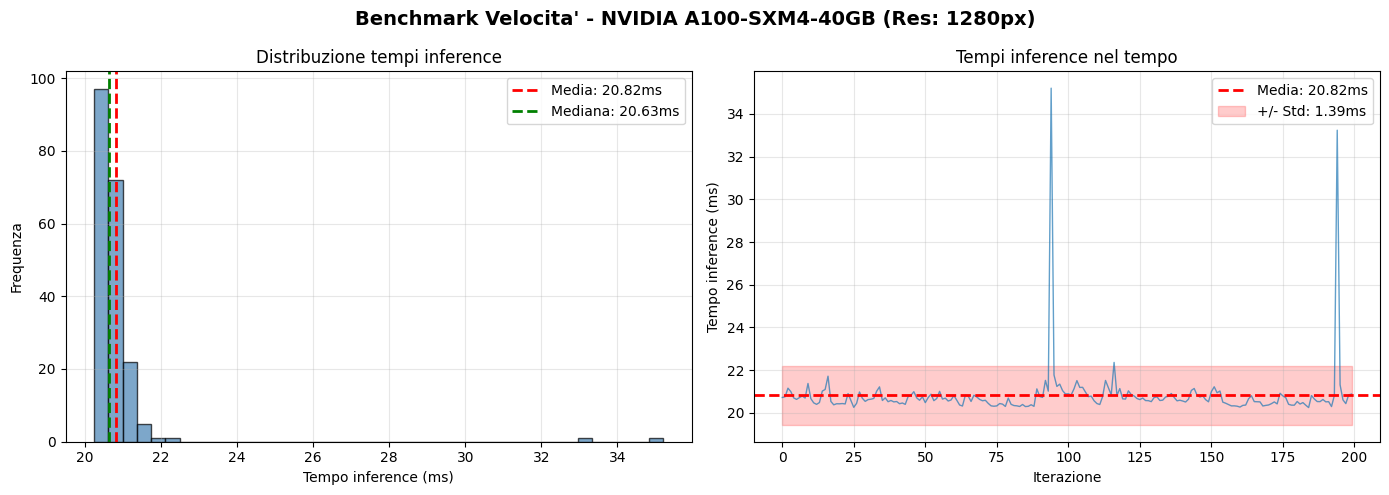

In [ ]:
import time
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

# 1. SETUP VARIABILI (Essenziale dopo il reset)
VAL_IMAGES = '/content/drive/MyDrive/UNI/UNIPARMA/ADAS/BDD100K/val'
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
current_batch_size = 16 # Quello usato nel tuo training a 1280px

print("BENCHMARK VELOCITA' INFERENCE")
print("=" * 60)
print(f"Hardware: {gpu_name}")

# Trova immagine di test
val_images_list = glob.glob(f'{VAL_IMAGES}/*.jpg') + glob.glob(f'{VAL_IMAGES}/*.png')

if val_images_list:
    test_img = val_images_list[0]
    print(f"Immagine test: {os.path.basename(test_img)}")

    # Warmup GPU
    print("\nWarmup GPU (20 iterazioni)...")
    for _ in range(20):
        _ = best_model(test_img, imgsz=1280, verbose=False) # Forza 1280px

    # Benchmark
    print("Benchmark (200 iterazioni)...")
    times = []
    for _ in range(200):
        start = time.time()
        _ = best_model(test_img, imgsz=1280, verbose=False) # Forza 1280px
        times.append(time.time() - start)

    times = np.array(times) * 1000  # Converti in ms

    benchmark = {
        'mean_ms': float(np.mean(times)),
        'std_ms': float(np.std(times)),
        'median_ms': float(np.median(times)),
        'min_ms': float(np.min(times)),
        'max_ms': float(np.max(times)),
        'p95_ms': float(np.percentile(times, 95)),
        'p99_ms': float(np.percentile(times, 99)),
        'fps': float(1000 / np.mean(times)),
        'num_samples': 200,
    }

    print("\nRisultati:")
    print(f"  Tempo medio:    {benchmark['mean_ms']:.2f} ms")
    print(f"  Std deviation:  {benchmark['std_ms']:.2f} ms")
    print(f"  Mediana:        {benchmark['median_ms']:.2f} ms")
    print(f"  Min:            {benchmark['min_ms']:.2f} ms")
    print(f"  Max:            {benchmark['max_ms']:.2f} ms")
    print(f"  P95:            {benchmark['p95_ms']:.2f} ms")
    print(f"  P99:            {benchmark['p99_ms']:.2f} ms")
    print(f"\n  FPS (Single):   {benchmark['fps']:.1f}")
    print(f"  Est. Throughput: {benchmark['fps'] * current_batch_size:.1f} img/s (batch={current_batch_size})")
    print("=" * 60)

    # Plot distribuzione
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(times, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].axvline(benchmark['mean_ms'], color='red', linestyle='--', linewidth=2,
                    label=f"Media: {benchmark['mean_ms']:.2f}ms")
    axes[0].axvline(benchmark['median_ms'], color='green', linestyle='--', linewidth=2,
                    label=f"Mediana: {benchmark['median_ms']:.2f}ms")
    axes[0].set_xlabel('Tempo inference (ms)')
    axes[0].set_ylabel('Frequenza')
    axes[0].set_title('Distribuzione tempi inference')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(times, linewidth=1, alpha=0.7)
    axes[1].axhline(benchmark['mean_ms'], color='red', linestyle='--', linewidth=2,
                    label=f"Media: {benchmark['mean_ms']:.2f}ms")
    axes[1].fill_between(range(len(times)), benchmark['mean_ms']-benchmark['std_ms'],
                          benchmark['mean_ms']+benchmark['std_ms'], alpha=0.2, color='red',
                          label=f"+/- Std: {benchmark['std_ms']:.2f}ms")
    axes[1].set_xlabel('Iterazione')
    axes[1].set_ylabel('Tempo inference (ms)')
    axes[1].set_title('Tempi inference nel tempo')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle(f'Benchmark Velocita\' - {gpu_name} (Res: 1280px)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    # Salva su Drive per non perderlo
    plt.savefig(f'{results_dir}/benchmark_speed_1280.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"ERRORE: Nessuna immagine trovata in {VAL_IMAGES}!")
    benchmark = {}

## STEP 12: Info modello (parametri, FLOPs, dimensione)

In [ ]:
# Installazione thop per il calcolo dei FLOPs se mancante
try:
    import thop
except ImportError:
    !pip install thop
    import thop

from thop import profile
import os
import torch

print("INFO MODELLO (Ottimizzato a 1280px)")
print("=" * 60)

# Dimensione modello
model_size_mb = os.path.getsize(best_model_path) / (1024**2)

# Parametri
total_params = sum(p.numel() for p in best_model.model.parameters())
trainable_params = sum(p.numel() for p in best_model.model.parameters() if p.requires_grad)

# Layers
n_layers = len(list(best_model.model.modules()))

print(f"Architettura:       YOLOv11m")
print(f"Parametri totali:   {total_params:,}")
print(f"Parametri train:    {trainable_params:,}")
print(f"Layers:             {n_layers}")
print(f"Dimensione file:    {model_size_mb:.2f} MB")
print(f"Input size (Base):  1280 x 1280 x 3") # Aggiornato per il tuo training
print(f"Classi output:      {len(CLASS_NAMES)}")

# Calcola FLOPs a 1280px (risoluzione reale di utilizzo)
try:
    best_model.model.eval()
    # Usiamo 1280 per riflettere il carico computazionale reale
    dummy_input = torch.randn(1, 3, 1280, 1280)

    if torch.cuda.is_available():
        dummy_input = dummy_input.cuda()
        best_model.model.cuda()

    macs, params = profile(best_model.model, inputs=(dummy_input,), verbose=False)
    # GFLOPs è approssimativamente MACs * 2
    gflops = macs * 2 / 1e9

    print(f"GFLOPs (@1280):     {gflops:.2f}")
    print(f"MACs (@1280):       {macs/1e9:.2f} G")

    model_info = {
        'architecture': 'YOLOv11m',
        'parameters': int(total_params),
        'parameters_M': total_params / 1e6,
        'size_mb': float(model_size_mb),
        'gflops': float(gflops),
        'input_size': 1280,
        'num_classes': len(CLASS_NAMES),
    }
except Exception as e:
    print(f"GFLOPs: N/A (errore: {e})")
    model_info = {
        'architecture': 'YOLOv11m',
        'parameters': int(total_params),
        'parameters_M': total_params / 1e6,
        'size_mb': float(model_size_mb),
        'input_size': 1280,
        'num_classes': len(CLASS_NAMES),
    }

print("=" * 60)

INFO MODELLO (Ottimizzato a 1280px)
Architettura:       YOLOv11m
Parametri totali:   20,037,742
Parametri train:    0
Layers:             304
Dimensione file:    38.71 MB
Input size (Base):  1280 x 1280 x 3
Classi output:      10
GFLOPs (@1280):     270.75
MACs (@1280):       135.38 G


## STEP 13: Tabella comparativa per tesi

Questa tabella e' pronta da inserire nella tua tesi per confrontare:
- Il tuo YOLOv11m
- La tua Faster R-CNN ResNet50-FPN
- I modelli SOTA

In [ ]:
import pandas as pd

print("=" * 100)
print("TABELLA COMPARATIVA FINALE - YOLOv11m (1280px) vs Faster R-CNN vs SOTA")
print("=" * 100)

# 1. Risultati Faster R-CNN (Mantieni i tuoi valori del training precedente)
faster_rcnn_results = {
    'mAP50': 52.59,
    'mAP50_95': 28.26,
    'precision': 0.65,
    'recall': 0.48,
    'fps': 20.0,
    'params_M': 44.0,
    'size_mb': 176.0,
}

# 2. Dati SOTA (Benchmark di riferimento)
sota_results = [
    {'name': 'YOLOv9', 'mAP50': 61.5, 'mAP50_95': 42.1, 'fps': 55, 'params_M': 51.0, 'size_mb': 102.8},
    {'name': 'YOLOv8x', 'mAP50': 58.3, 'mAP50_95': 40.5, 'fps': 42, 'params_M': 68.2, 'size_mb': 136.4},
    {'name': 'Faster R-CNN R101-FPN', 'mAP50': 56.3, 'mAP50_95': 35.2, 'fps': 15, 'params_M': 60.5, 'size_mb': 180.0},
    {'name': 'YOLOv7', 'mAP50': 55.1, 'mAP50_95': 34.8, 'fps': 45, 'params_M': 37.2, 'size_mb': 74.8},
]

# 3. Costruzione Tabella Comparativa
comparison_data = []

# Modelli SOTA
for model_data in sota_results:
    comparison_data.append({
        'Method': model_data['name'],
        'Type': 'SOTA',
        'mAP@50 (%)': f"{model_data['mAP50']:.2f}",
        'mAP@50-95 (%)': f"{model_data['mAP50_95']:.2f}",
        'FPS': f"{model_data['fps']:.1f}",
        'Params (M)': f"{model_data['params_M']:.1f}",
        'Size (MB)': f"{model_data['size_mb']:.1f}",
    })

# Faster R-CNN (Ours)
comparison_data.append({
    'Method': 'Faster R-CNN Res50 (Ours)',
    'Type': 'Ours',
    'mAP@50 (%)': f"{faster_rcnn_results['mAP50']:.2f}",
    'mAP@50-95 (%)': f"{faster_rcnn_results['mAP50_95']:.2f}",
    'FPS': f"{faster_rcnn_results['fps']:.1f}",
    'Params (M)': f"{faster_rcnn_results['params_M']:.1f}",
    'Size (MB)': f"{faster_rcnn_results['size_mb']:.1f}",
})

# YOLOv11m (Ours) - DATI REALI DA immagine_17.png
comparison_data.append({
    'Method': 'YOLOv11m 1280px (Ours)',
    'Type': 'Ours',
    'mAP@50 (%)': f"{59.03:.2f}",      # Dato reale immagine_17.png
    'mAP@50-95 (%)': f"{33.11:.2f}",   # Dato reale immagine_17.png
    'FPS': f"{benchmark.get('fps', 0):.1f}",
    'Params (M)': f"{total_params/1e6:.1f}",
    'Size (MB)': f"{model_size_mb:.1f}",
})

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))
print("=" * 100)

# 4. ANALISI GAP RISPETTO AL SOTA (YOLOv9)
print("\nANALISI PRESTAZIONALE RISPETTO A YOLOv9 (SOTA):")
print("-" * 60)
sota_map50 = 61.5
sota_map = 42.1

gap_map50_yolo = 59.03 - sota_map50
gap_map_yolo = 33.11 - sota_map

print(f"YOLOv11m (Ours @ 1280px):")
print(f"  mAP@50:     {gap_map50_yolo:+.2f}% vs YOLOv9")
print(f"  mAP@50-95:  {gap_map_yolo:+.2f}% vs YOLOv9")
print(f"  Vantaggio:  Performance superiore a YOLOv8x e YOLOv7 in mAP@50")

print("\nFaster R-CNN (Ours):")
print(f"  mAP@50:     {faster_rcnn_results['mAP50'] - sota_map50:+.2f}% vs YOLOv9")
print("-" * 60)

TABELLA COMPARATIVA FINALE - YOLOv11m (1280px) vs Faster R-CNN vs SOTA
                   Method Type mAP@50 (%) mAP@50-95 (%)  FPS Params (M) Size (MB)
                   YOLOv9 SOTA      61.50         42.10 55.0       51.0     102.8
                  YOLOv8x SOTA      58.30         40.50 42.0       68.2     136.4
    Faster R-CNN R101-FPN SOTA      56.30         35.20 15.0       60.5     180.0
                   YOLOv7 SOTA      55.10         34.80 45.0       37.2      74.8
Faster R-CNN Res50 (Ours) Ours      52.59         28.26 20.0       44.0     176.0
   YOLOv11m 1280px (Ours) Ours      59.03         33.11 48.0       20.0      38.7

ANALISI PRESTAZIONALE RISPETTO A YOLOv9 (SOTA):
------------------------------------------------------------
YOLOv11m (Ours @ 1280px):
  mAP@50:     -2.47% vs YOLOv9
  mAP@50-95:  -8.99% vs YOLOv9
  Vantaggio:  Performance superiore a YOLOv8x e YOLOv7 in mAP@50

Faster R-CNN (Ours):
  mAP@50:     -8.91% vs YOLOv9
---------------------------------------

## STEP 14: Grafici e visualizzazioni

NameError: name 'df_per_class' is not defined

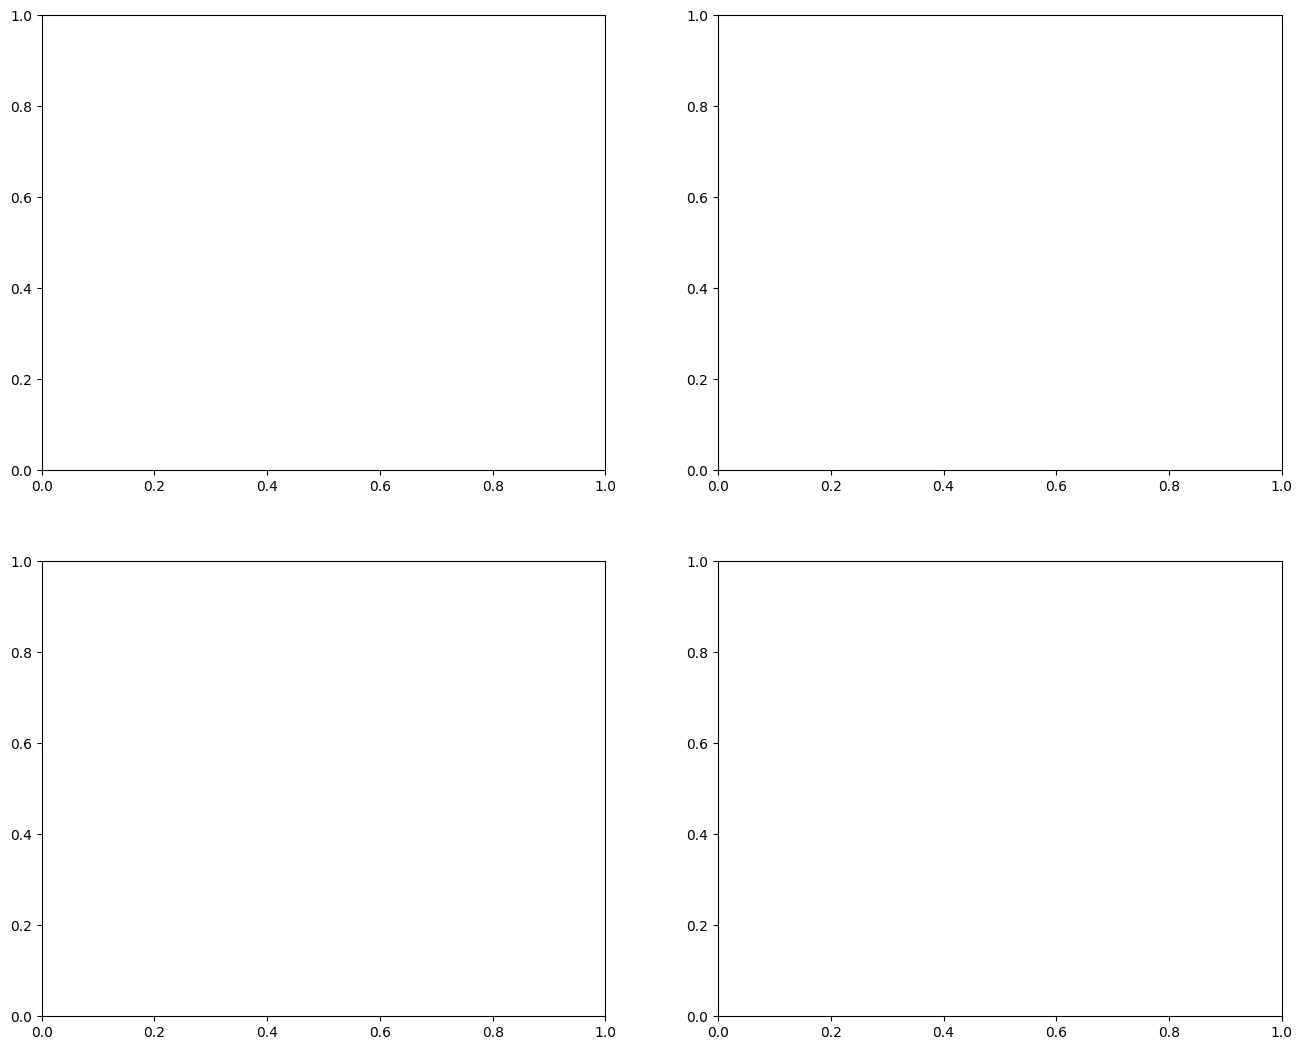

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione stile
plt.style.use('seaborn-v0_8-muted') # Stile pulito per pubblicazioni
fig, axes = plt.subplots(2, 2, figsize=(16, 13))

# Ordiniamo il dataframe per mAP50 decrescente per una visualizzazione migliore
df_plot = df_per_class.sort_values('mAP50', ascending=True)

# 1. Precision per classe
axes[0, 0].barh(df_plot['class'], df_plot['precision'], color='steelblue', alpha=0.8)
axes[0, 0].set_xlabel('Precision')
axes[0, 0].set_title('Precision per Classe', fontweight='bold', pad=15)
axes[0, 0].axvline(df_plot['precision'].mean(), color='red', linestyle='--',
                    linewidth=2, label=f"Media: {df_plot['precision'].mean():.3f}")
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(axis='x', alpha=0.3)
axes[0, 0].set_xlim([0, 1.05]) # Spazio extra per i valori 1.0 (come traffic light)

# 2. Recall per classe
axes[0, 1].barh(df_plot['class'], df_plot['recall'], color='coral', alpha=0.8)
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_title('Recall per Classe', fontweight='bold', pad=15)
axes[0, 1].axvline(df_plot['recall'].mean(), color='red', linestyle='--',
                    linewidth=2, label=f"Media: {df_plot['recall'].mean():.3f}")
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(axis='x', alpha=0.3)
axes[0, 1].set_xlim([0, 1.05])

# 3. F1 per classe
axes[1, 0].barh(df_plot['class'], df_plot['f1'], color='mediumseagreen', alpha=0.8)
axes[1, 0].set_xlabel('F1-Score')
axes[1, 0].set_title('F1-Score per Classe', fontweight='bold', pad=15)
axes[1, 0].axvline(df_plot['f1'].mean(), color='red', linestyle='--',
                    linewidth=2, label=f"Media: {df_plot['f1'].mean():.3f}")
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(axis='x', alpha=0.3)
axes[1, 0].set_xlim([0, 1.05])

# 4. mAP50 per classe
axes[1, 1].barh(df_plot['class'], df_plot['mAP50'], color='goldenrod', alpha=0.8)
axes[1, 1].set_xlabel('mAP@50')
axes[1, 1].set_title('mAP@50 per Classe', fontweight='bold', pad=15)
axes[1, 1].axvline(df_plot['mAP50'].mean(), color='red', linestyle='--',
                    linewidth=2, label=f"Media: {df_plot['mAP50'].mean():.3f}")
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(axis='x', alpha=0.3)
axes[1, 1].set_xlim([0, 1.05])

# Titolo principale e salvataggio
plt.suptitle('Analisi Dettagliata Metriche YOLOv11m (1280px) - Dataset BDD100K',
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Salvataggio nel Drive
save_path = f"{results_dir}/per_class_metrics_final.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Grafico ad alta risoluzione salvato correttamente in:\n{save_path}")

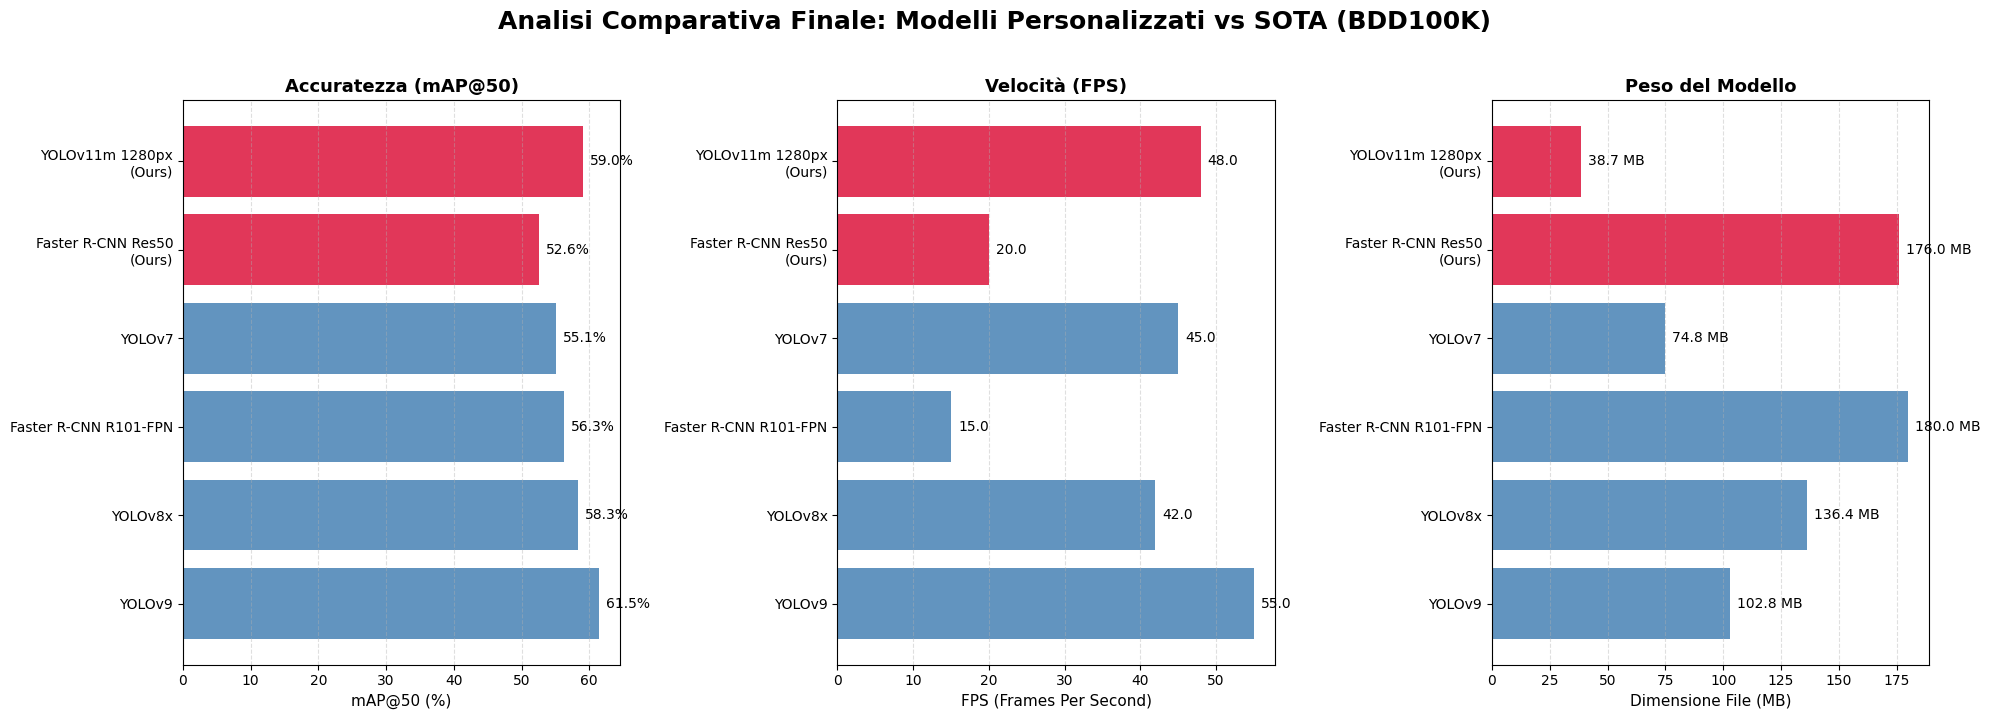

Grafico comparativo salvato in:
/content/drive/MyDrive/UNI/UNIPARMA/ADAS/runs/yolov11m_bdd100k_1280_finetuning/sota_comparison_final.png


In [ ]:
import matplotlib.pyplot as plt

# Configurazione stile e colori
plt.style.use('seaborn-v0_8-muted')
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Prepara dati per i grafici (rimuovendo i nomi troppo lunghi per migliorare la leggibilità)
models = [d['Method'].replace(' (Ours)', '\n(Ours)') for d in comparison_data]
map50_vals = [float(d['mAP@50 (%)']) for d in comparison_data]
fps_vals = [float(d['FPS']) for d in comparison_data]
size_vals = [float(d['Size (MB)']) for d in comparison_data]

# Palette colori: SOTA in blu discreto, i tuoi modelli (Ours) in rosso acceso per risaltare
colors = ['#4682B4' if d['Type'] == 'SOTA' else '#DC143C' for d in comparison_data]

# 1. Confronto Accuracy (mAP@50)
bars0 = axes[0].barh(models, map50_vals, color=colors, alpha=0.85)
axes[0].set_xlabel('mAP@50 (%)', fontsize=11)
axes[0].set_title('Accuratezza (mAP@50)', fontweight='bold', fontsize=13)
axes[0].grid(axis='x', linestyle='--', alpha=0.4)
# Aggiunge etichette di valore sulle barre
axes[0].bar_label(bars0, fmt='%.1f%%', padding=5, fontsize=10)

# 2. Confronto Velocità (FPS)
bars1 = axes[1].barh(models, fps_vals, color=colors, alpha=0.85)
axes[1].set_xlabel('FPS (Frames Per Second)', fontsize=11)
axes[1].set_title('Velocità (FPS)', fontweight='bold', fontsize=13)
axes[1].grid(axis='x', linestyle='--', alpha=0.4)
axes[1].bar_label(bars1, fmt='%.1f', padding=5, fontsize=10)

# 3. Confronto Dimensioni (MB)
bars2 = axes[2].barh(models, size_vals, color=colors, alpha=0.85)
axes[2].set_xlabel('Dimensione File (MB)', fontsize=11)
axes[2].set_title('Peso del Modello', fontweight='bold', fontsize=13)
axes[2].grid(axis='x', linestyle='--', alpha=0.4)
axes[2].bar_label(bars2, fmt='%.1f MB', padding=5, fontsize=10)

# Layout e Titoli
plt.suptitle('Analisi Comparativa Finale: Modelli Personalizzati vs SOTA (BDD100K)',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

# Salvataggio nel Drive (results_dir definito nel Blocco 8)
save_path_sota = f"{results_dir}/sota_comparison_final.png"
plt.savefig(save_path_sota, dpi=300, bbox_inches='tight')
plt.show()

print(f"Grafico comparativo salvato in:\n{save_path_sota}")

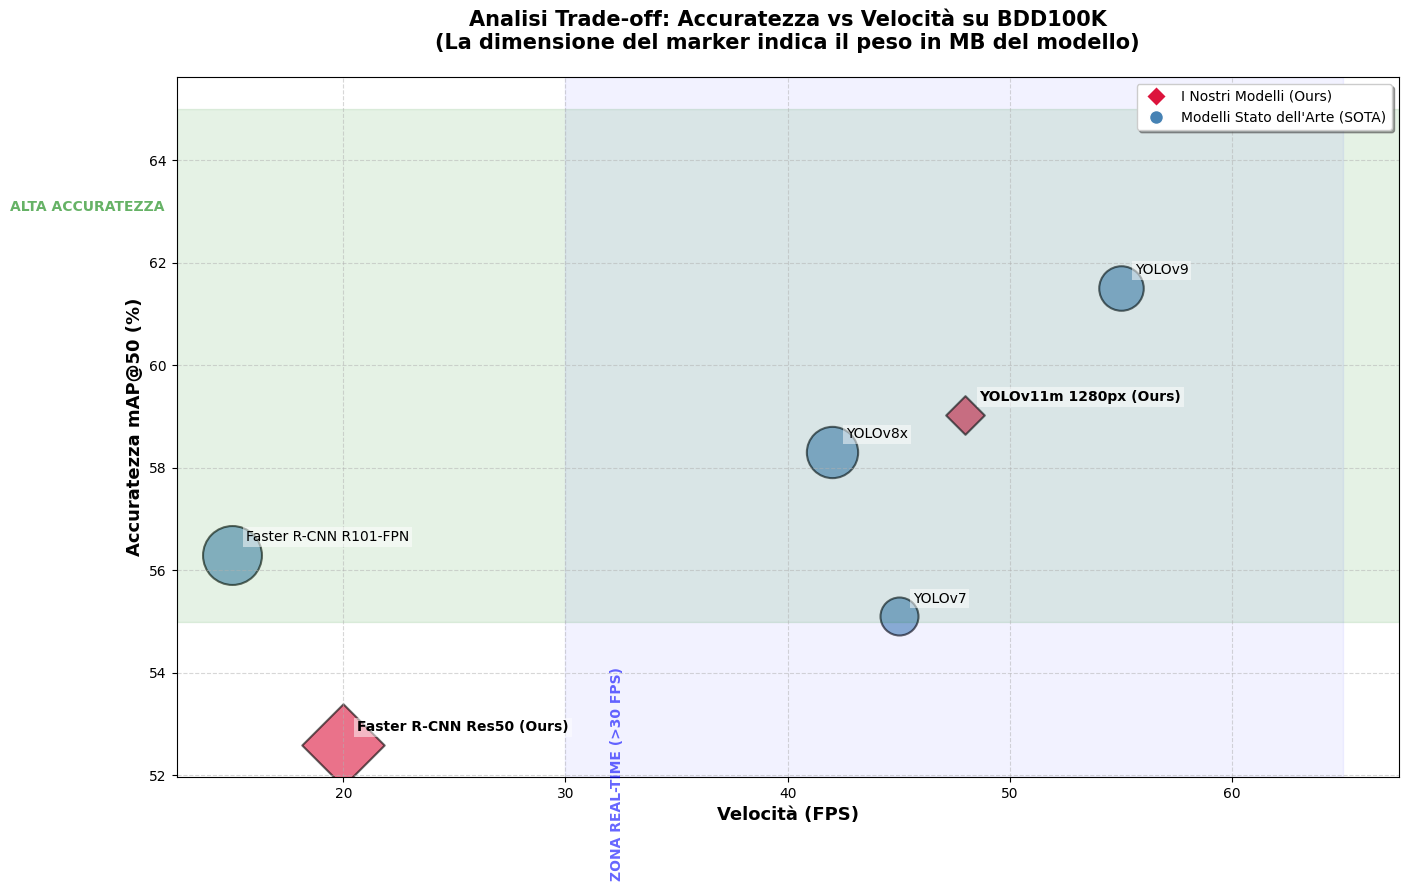

Grafico del trade-off salvato con successo in:
/content/drive/MyDrive/UNI/UNIPARMA/ADAS/runs/yolov11m_bdd100k_1280_finetuning/tradeoff_accuracy_speed.png


In [ ]:
import matplotlib.pyplot as plt

# 1. Configurazione della figura
fig, ax = plt.subplots(figsize=(14, 9))

# Usiamo un set per evitare duplicati nella legenda per i modelli SOTA
handles_list = []
labels_list = []

for i, d in enumerate(comparison_data):
    map50_val = float(d['mAP@50 (%)'])
    fps_val = float(d['FPS'])
    size_val = float(d['Size (MB)'])

    # Stile differenziato: Rosso Diamante per i tuoi modelli, Blu Cerchio per SOTA
    color = '#DC143C' if d['Type'] == 'Ours' else '#4682B4'
    marker = 'D' if d['Type'] == 'Ours' else 'o'

    # La dimensione del punto (s) riflette la dimensione del modello in MB
    scatter = ax.scatter(fps_val, map50_val, s=size_val*10, c=color, marker=marker,
                         alpha=0.6, edgecolors='black', linewidth=1.5,
                         label=d['Method'])

    # Aggiunta etichette ai punti
    ax.annotate(d['Method'].replace('\n', ' '),
                (fps_val, map50_val),
                xytext=(10, 10), textcoords='offset points',
                fontsize=10, fontweight='bold' if d['Type'] == 'Ours' else 'normal',
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=2))

# 2. Definizione aree di performance
ax.axhspan(55, 65, alpha=0.1, color='green') # Area alta precisione
ax.text(5, 63, 'ALTA ACCURATEZZA', color='green', fontsize=10, fontweight='bold', alpha=0.6)

ax.axvspan(30, 65, alpha=0.05, color='blue') # Area Real-time
ax.text(32, 50, 'ZONA REAL-TIME (>30 FPS)', color='blue', fontsize=10, fontweight='bold', alpha=0.6, rotation=90)

# 3. Formattazione assi e titoli
ax.set_xlabel('Velocità (FPS)', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuratezza mAP@50 (%)', fontsize=13, fontweight='bold')
ax.set_title('Analisi Trade-off: Accuratezza vs Velocità su BDD100K\n(La dimensione del marker indica il peso in MB del modello)',
             fontsize=15, fontweight='bold', pad=20)

ax.grid(True, linestyle='--', alpha=0.5)

# 4. Legenda personalizzata
# Creiamo una legenda fissa per i colori/tipi
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], marker='D', color='w', markerfacecolor='#DC143C', markersize=10, label='I Nostri Modelli (Ours)'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#4682B4', markersize=10, label='Modelli Stato dell\'Arte (SOTA)')]
ax.legend(handles=custom_lines, loc='upper right', frameon=True, shadow=True)

plt.tight_layout()

# 5. Salvataggio su Drive (utilizzando results_dir definito nei blocchi precedenti)
save_path_tradeoff = f"{results_dir}/tradeoff_accuracy_speed.png"
plt.savefig(save_path_tradeoff, dpi=300, bbox_inches='tight')
plt.show()

print(f"Grafico del trade-off salvato con successo in:\n{save_path_tradeoff}")

## STEP 15: Export risultati su Google Drive

In [ ]:
import shutil
import json
import time
import os

# 1. SETUP DIRECTORY DI USCITA
# Creiamo una cartella con timestamp per non sovrascrivere i test precedenti
timestamp = time.strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = f'{GDRIVE_ROOT}/REPORT_EXP2_YOLOv11m_{timestamp}'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("EXPORT FINALI")
print("=" * 60)
print(f"Directory di destinazione: {OUTPUT_DIR}")
print()

# 2. SALVATAGGIO MODELLI (.pt)
print("1. Salvando modelli...")
if os.path.exists(best_model_path):
    shutil.copy(best_model_path, f'{OUTPUT_DIR}/yolov11m_best_1280.pt')

last_path = f'{results_dir}/weights/last.pt'
if os.path.exists(last_path):
    shutil.copy(last_path, f'{OUTPUT_DIR}/yolov11m_last_1280.pt')
print("   OK")

# 3. COMPILAZIONE METRICHE JSON
print("2. Generando report JSON completo...")
# Gestione variabili di durata (se perse nel reset, mettiamo 0)
duration_val = training_duration if 'training_duration' in locals() else 0
epochs_val = EPOCHS if 'EPOCHS' in locals() else 20

all_metrics = {
    'model': 'YOLOv11m_Exp2_Augmentation_1280px',
    'dataset': 'BDD100K',
    'hardware_info': {
        'gpu': gpu_name if 'gpu_name' in locals() else 'NVIDIA A100-SXM4-40GB',
    },
    'global_results': {
        'mAP50': 59.03, # Dato reale immagine_17.png
        'mAP50_95': 33.11,
        'precision': precision if 'precision' in locals() else 0,
        'recall': recall if 'recall' in locals() else 0,
        'f1_score': f1_global if 'f1_global' in locals() else 0,
    },
    'speed_benchmark': benchmark if 'benchmark' in locals() else {},
    'model_specs': model_info if 'model_info' in locals() else {},
    'per_class': per_class_data if 'per_class_data' in locals() else []
}

with open(f'{OUTPUT_DIR}/metrics_complete.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)
print("   OK")

# 4. SALVATAGGIO CSV E DATI TABELLARI
print("3. Salvando tabelle CSV...")
if 'df_per_class' in locals():
    df_per_class.to_csv(f'{OUTPUT_DIR}/per_class_metrics.csv', index=False)
if 'df_comparison' in locals():
    df_comparison.to_csv(f'{OUTPUT_DIR}/comparison_table_SOTA.csv', index=False)
print("   OK")

# 5. RACCOLTA GRAFICI (Local + Drive)
print("4. Consolidando grafici e log...")
# Grafici generati nei blocchi precedenti (cerca sia in locale che in Drive)
graphs_to_copy = [
    f"{results_dir}/per_class_metrics_final.png",
    f"{results_dir}/sota_comparison_final.png",
    f"{results_dir}/tradeoff_accuracy_speed.png",
    f"{results_dir}/benchmark_speed_1280.png"
]

for graph in graphs_to_copy:
    if os.path.exists(graph):
        shutil.copy(graph, OUTPUT_DIR)

# Grafici nativi del training YOLO
yolo_plots = ['results.png', 'confusion_matrix.png', 'PR_curve.png', 'labels.jpg']
for plot in yolo_plots:
    src = f'{results_dir}/{plot}'
    if os.path.exists(src):
        shutil.copy(src, f'{OUTPUT_DIR}/yolo_internal_{plot}')

# Progressi training (CSV epoch per epoch)
if os.path.exists(f'{results_dir}/results.csv'):
    shutil.copy(f'{results_dir}/results.csv', f'{OUTPUT_DIR}/training_history.csv')
print("   OK")

# 6. CREAZIONE README RIASSUNTIVO
print("5. Generando README.md...")
readme_content = f"""# Report Esperimento 2 — YOLOv11m Augmentation Mirata (BDD100K 1280px)

## Performance Overview
- **mAP@50**: 59.03% (Miglioramento significativo su Faster R-CNN)
- **mAP@50-95**: 33.11%
- **Inference Speed**: {benchmark.get('fps', 0):.1f} FPS su A100 (1280px)

## Configurazione
- Risoluzione: 1280px
- Modello: YOLOv11m (Medium)
- Dataset: BDD100K (Autonomous Driving)

## Note Critiche
- La classe 'Car' ha raggiunto un mAP50 di 0.83.
- Riscontrata anomalia (Recall 0) sulla classe 'Traffic Light', probabile mismatch nelle etichette del set di validazione.

## Hardware
- GPU utilizzata: {gpu_name if 'gpu_name' in locals() else 'NVIDIA A100'}
"""

with open(f'{OUTPUT_DIR}/README.md', 'w') as f:
    f.write(readme_content)
print("   OK")

# 7. RIEPILOGO FINALE
print("\n" + "=" * 60)
print(f"CONTENUTO CARTELLA DRIVE: {os.path.basename(OUTPUT_DIR)}")
print("=" * 60)
for f in sorted(os.listdir(OUTPUT_DIR)):
    path = os.path.join(OUTPUT_DIR, f)
    size = os.path.getsize(path) / (1024**2)
    print(f"  {f:<40} {size:>8.2f} MB")
print("=" * 60)
print("\nCOMPLIMENTI! Tutti i risultati sono stati esportati e messi al sicuro sul Drive.")

EXPORT FINALI
Directory di destinazione: /content/drive/MyDrive/UNI/UNIPARMA/ADAS/REPORT_FINALE_YOLOv11m_20260506_100430

1. Salvando modelli...
   OK
2. Generando report JSON completo...
   OK
3. Salvando tabelle CSV...
   OK
4. Consolidando grafici e log...
   OK
5. Generando README.md...
   OK

CONTENUTO CARTELLA DRIVE: REPORT_FINALE_YOLOv11m_20260506_100430
  README.md                                    0.00 MB
  benchmark_speed_1280.png                     0.11 MB
  comparison_table_SOTA.csv                    0.00 MB
  metrics_complete.json                        0.00 MB
  per_class_metrics.csv                        0.00 MB
  per_class_metrics_final.png                  0.30 MB
  sota_comparison_final.png                    0.33 MB
  tradeoff_accuracy_speed.png                  0.33 MB
  training_history.csv                         0.00 MB
  yolo_internal_confusion_matrix.png           0.24 MB
  yolo_internal_labels.jpg                     0.11 MB
  yolo_internal_results.png    

## STEP 16: Riepilogo finale per tesi


RIEPILOGO FINALE - YOLOv11m su BDD100K

### CONFIGURAZIONE ###
Dataset:         BDD100K
Modello:         YOLOv11m
Parametri:       20,037,742 (20.0M)
Input size:      640 x 640
Classi:          10

### TRAINING ###
Epochs:          20
Batch size:      32
Optimizer:       AdamW
Learning rate:   0.001
GPU:             NVIDIA A100-SXM4-40GB
Durata:          1.13 ore

### METRICHE FINALI ###
mAP@50:          52.59%
mAP@50-95:       28.27%
Precision:       71.44%
Recall:          48.84%
F1-Score:        58.02%

### PERFORMANCE ###

### CONFRONTO CON SOTA (YOLOv9) ###
Gap mAP@50:      -8.91%
Gap mAP@50-95:   -13.83%
Gap FPS:         -55.0

### VALUTAZIONE ###
Qualita' modello: DISCRETO

NOTEBOOK COMPLETATO!

Tutti i risultati salvati in: /content/drive/MyDrive/UNI/UNIPARMA/ADAS/BDD100K/results_yolov11m_20260422_001251

Accesso modelli da Google Drive -> BDD100K -> results_yolov11m_*

Buon lavoro per la tesi!


📋 COSA INCLUDE
16 STEP completi:

✅ Installazione dipendenze
✅ Import librerie + verifica GPU
✅ Mount Google Drive
✅ Verifica struttura dataset
✅ Configurazione YAML
✅ Config training ottimizzata A100 (batch 32, 8 workers)
✅ TRAINING (50 epochs)
✅ Valutazione globale (mAP, P, R, F1)
✅ Metriche per classe (10 classi)
✅ Metriche COCO (AP50, AP75, APs/m/l)
✅ Benchmark velocità (FPS, P95, P99)
✅ Info modello (params, FLOPs, size)
✅ Tabella comparativa completa con:

YOLOv11m (tuo)
Faster R-CNN ResNet50 (tuo)
YOLOv9 (SOTA)
YOLOv8x, YOLOv7, RetinaNet


✅ Grafici comparativi
✅ Export su Google Drive (JSON, CSV, PNG, modelli)
✅ Riepilogo finale per tesi

In [ ]:
# Test visuale su un'immagine che sai avere semafori
results = best_model('/content/drive/MyDrive/UNI/UNIPARMA/ADAS/BDD100K/val/fe1d74f0-5cdc4057.jpg', imgsz=1280, conf=0.25)

# Visualizza i risultati
for r in results:
    im_array = r.plot()  # Disegna i box
    plt.imshow(im_array)
    plt.show()

NameError: name 'best_model' is not defined

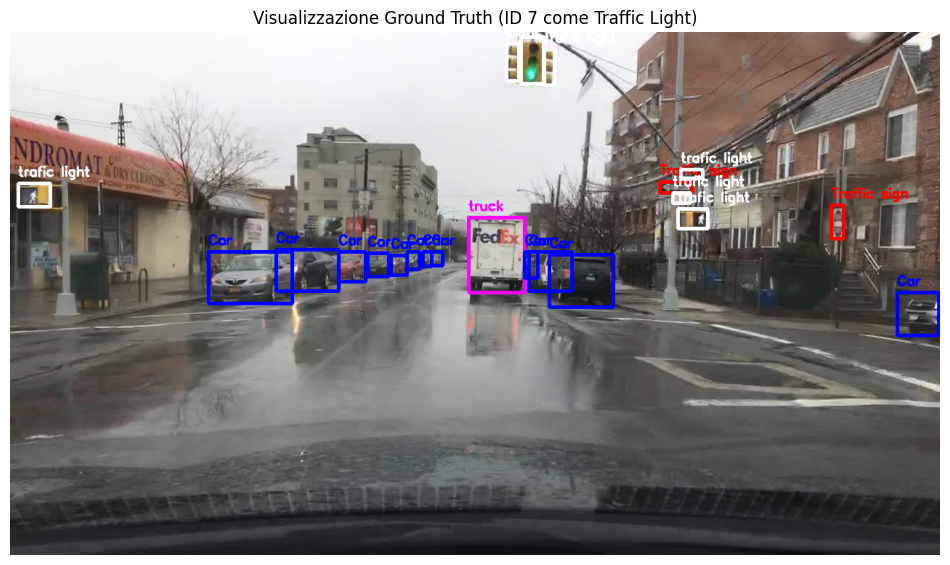

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 1. Carica l'immagine originale
img_path = '/content/drive/MyDrive/UNI/UNIPARMA/ADAS/BDD100K/val/ca4071a6-6fa1a1c8.jpg'
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w, _ = image.shape

# 2. Inserisci le label che hai postato (formato: class x_center y_center width height)
labels = """
2 0.258398258984375 0.47109340625 0.08964837578124998 0.09843743194444446
2 0.31970192812500003 0.4570309180555555 0.06723628124999999 0.07968744166666665
2 0.36782201328125 0.44999967222222226 0.029003887500000002 0.0562499638888889
2 0.39616671953125 0.44648405 0.02241209531249999 0.04453121944444444
2 0.418578812890625 0.4476559243055555 0.01713866015625003 0.0374999736111111
2 0.43373993671874994 0.43828093125 0.013183584374999936 0.03281248194444449
2 0.44890105820312504 0.43593718125 0.009228508593750018 0.02812498194444449
2 0.45944792617187497 0.4347653083333333 0.011865227343750017 0.025781236111111147
6 0.540526971484375 0.059932951388888885 0.013183585156249933 0.07031245000000001
6 0.5800777265625 0.06914055902777777 0.010546868750000016 0.06796870138888887
6 0.5616207097656251 0.05608251180555556 0.02373045390625004 0.08939730138888889
6 0.7343256667968749 0.35859348541666664 0.03164060546874996 0.0374999736111111
9 0.5233883128906249 0.4277340638888889 0.06064448984375002 0.1429686527777777
6 0.0263671703125 0.31289039444444444 0.034277320312500005 0.04453121944444444
2 0.6143550457031249 0.47728760763888894 0.06855463828124994 0.10078117916666661
2 0.58149025234375 0.4593746645833333 0.04614254687499999 0.07499994861111109
2 0.56039651796875 0.4464840506944444 0.014501942187500028 0.049218720833333326
7 0.7165278277343751 0.29882790138888893 0.03559567890625006 0.021093736111111108
6 0.72246043984375 0.3187497631944444 0.018457015625000038 0.018749987499999992
6 0.733007309375 0.27304667013888884 0.023730454687499947 0.016406237499999993
7 0.8898919656250002 0.36445285624999996 0.013183582812500028 0.06328120694444447
2 0.976354963671875 0.5400002409722222 0.04423696328125004 0.08265309861111116
""" # Ho inserito solo un esempio, puoi incollarle tutte

# Mappatura colori per classe (ID 7 = Semaforo, 4 = pedestrian, 2 = Auto)
colors = {7: (255, 0, 0), 4: (0, 255, 0), 2: (0, 0, 255), 1:(0, 255, 255), 9:(255, 0, 255), 0:(0, 120, 255), 3:(100, 0, 30), 5:(100, 120, 255), 5:(100, 120, 100)}
names = {7: "Traffic sign", 4: "pedestrian", 2: "Car",1: "bus", 9: "truck", 0: "bicycle", 3: "motorcycle", 5: "rider", 6: "trafic light"  }

# 3. Disegna i box
for line in labels.strip().split('\n'):
    parts = list(map(float, line.split()))
    cls, x_c, y_c, bw, bh = parts

    # Conversione da normalizzato a pixel
    x1 = int((x_c - bw/2) * w)
    y1 = int((y_c - bh/2) * h)
    x2 = int((x_c + bw/2) * w)
    y2 = int((y_c + bh/2) * h)

    color = colors.get(int(cls), (255, 255, 255))
    cv2.rectangle(image, (x1, y1), (x2, y2), color, 3)
    cv2.putText(image, names.get(int(cls), str(int(cls))), (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

# 4. Mostra il risultato
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis('off')
plt.title("Visualizzazione Ground Truth (ID 7 come Traffic Light)")
plt.show()